In [1]:
# thanks to https://towardsdatascience.com/topic-modeling-with-bert-779f7db187e6 
# for the code and idea

In [2]:
import pickle as pkl, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import hdbscan
from sklearn.feature_extraction.text import CountVectorizer
import plotly.express as px


In [3]:
# Load data downloaded from MDB
with open('Downloads/samplePosts.pkl', 'rb') as handle:
    samplePosts = pkl.load(handle)

In [4]:
# separate out different fields from data
ids = [x['id'] for x in samplePosts]
texts = [x['selftext'] for x in samplePosts]
titles = [x['selftext'] for x in samplePosts]
vectors = [x['selftextVector'] for x in samplePosts]

In [5]:
vectors = np.array(vectors)

## Steps:
1. Reduce Embeddings Dimensionality to 5 via UMAP
2. Cluster documents based on the 5 dimensions to get cluster labels
3. Reduce Embeddings Dimensionality to 2 via UMAP
4. Plot these 2 dimensions with Cluster Label Overlay
5. Compute word importance per cluster

In [6]:
# Dimensionality Reduction 1: Reduce to 5 dims
umap_embeddings = umap.UMAP(n_neighbors=15, 
                            n_components=5, 
                            metric='cosine').fit_transform(vectors)

In [7]:
# Cluster docs based on 5 dims from above
clusters_umap = hdbscan.HDBSCAN(min_cluster_size=5,
                          metric='euclidean',                      
                          cluster_selection_method='eom').fit(umap_embeddings)

In [8]:
# Dimensionality Reduction 2: Reduce to 2 dims for plotting
umap_2d = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine').fit_transform(vectors)

In [9]:
plt.style.use("dark_background")

Text(0.5, 1.0, 'Document Clusters After Dimensionality Reduction (2 Dims). Gray Colour = Outliers, Colour = Cluster')

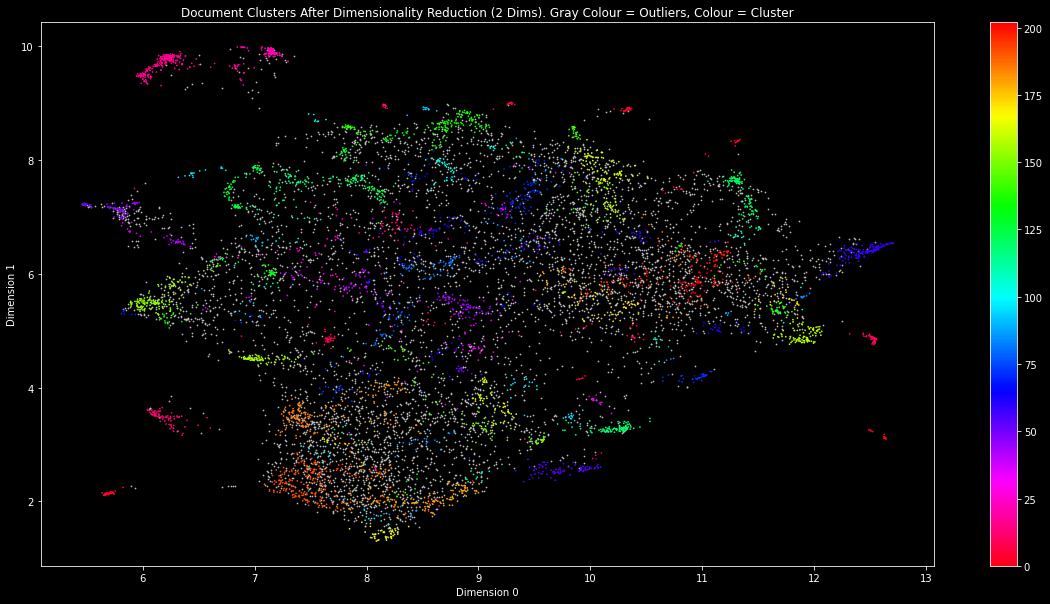

In [10]:
# Prepare data
result = pd.DataFrame(umap_2d, columns=['x', 'y'])
result['labels'] = clusters_umap.labels_
# Visualize clusters
fig, ax = plt.subplots(figsize=(20, 10))
outliers = result.loc[result.labels == -1, :]
clustered = result.loc[result.labels != -1, :]
plt.scatter(outliers.x, outliers.y, color='#BDBDBD', s=0.5)
plt.scatter(clustered.x, clustered.y, c=clustered.labels, s=0.5, cmap='hsv_r')
plt.colorbar()
plt.xlabel("Dimension 0")
plt.ylabel("Dimension 1")
plt.title("Document Clusters After Dimensionality Reduction (2 Dims). Gray Colour = Outliers, Colour = Cluster")


In [11]:
docs_df = pd.DataFrame(texts, columns=["Text"])
docs_df['Topic'] = clusters_umap.labels_
docs_df['Doc_ID'] = range(len(docs_df))
docs_per_topic = docs_df.groupby(['Topic'], as_index = False).agg({'Text': ' '.join})

In [12]:
def c_tf_idf(documents, m, ngram_range=(1, 1)):
    count = CountVectorizer(ngram_range=ngram_range, stop_words="english").fit(documents)
    t = count.transform(documents).toarray()
    w = t.sum(axis=1)
    tf = np.divide(t.T, w)
    sum_t = t.sum(axis=0)
    idf = np.log(np.divide(m, sum_t)).reshape(-1, 1)
    tf_idf = np.multiply(tf, idf)

    return tf_idf, count
  
tf_idf, count = c_tf_idf(docs_per_topic.Text.values, m=len(texts))

In [13]:
def extract_top_n_words_per_topic(tf_idf, count, docs_per_topic, n=20):
    words = count.get_feature_names()
    labels = list(docs_per_topic.Topic)
    tf_idf_transposed = tf_idf.T
    indices = tf_idf_transposed.argsort()[:, -n:]
    top_n_words = {label: [(words[j], tf_idf_transposed[i][j]) for j in indices[i]][::-1] for i, label in enumerate(labels)}
    return top_n_words

def extract_topic_sizes(df):
    topic_sizes = (df.groupby(['Topic'])
                     .Text
                     .count()
                     .reset_index()
                     .rename({"Topic": "Topic", "Text": "Size"}, axis='columns')
                     .sort_values("Size", ascending=False))
    return topic_sizes

top_n_words = extract_top_n_words_per_topic(tf_idf, count, docs_per_topic, n=20)
topic_sizes = extract_topic_sizes(docs_df); 
topic_sizes.head(10)

,Topic,Size
0,-1,5423
17,16,231
192,191,221
59,58,131
180,179,116
154,153,109
120,119,107
138,137,106
159,158,95
22,21,86


In [14]:
topic_sizes.sort_values('Size', ascending=False, inplace=True)

In [15]:
topic_sizes.head(10)

,Topic,Size
0,-1,5423
17,16,231
192,191,221
59,58,131
180,179,116
154,153,109
120,119,107
138,137,106
159,158,95
22,21,86


In [16]:
topic_sizes.shape

(204, 2)

In [22]:
pd.DataFrame(top_n_words[-1][:10], columns=['Word','TFIDF'])

,Word,TFIDF
0,sister,0.003124
1,parents,0.002889
2,brother,0.002855
3,talk,0.002832
4,house,0.002822
5,went,0.002815
6,school,0.002801
7,dad,0.002800
8,say,0.002800
9,help,0.002798


In [21]:
pd.DataFrame(top_n_words[16][:10], columns=['Word','TFIDF'])

,Word,TFIDF
0,dog,0.072302
1,dogs,0.027420
2,puppy,0.015802
3,vet,0.009937
4,yard,0.007698
5,walk,0.006936
6,leash,0.006732
7,care,0.006381
8,pet,0.006304
9,barking,0.005896


In [23]:
pd.DataFrame(top_n_words[191][:10], columns=['Word','TFIDF'])

,Word,TFIDF
0,ex,0.019174
1,feelings,0.011745
2,relationship,0.011724
3,broke,0.011470
4,dating,0.009835
5,girl,0.008187
6,friendship,0.007744
7,talking,0.007316
8,break,0.007120
9,months,0.007116


In [24]:
pd.DataFrame(top_n_words[58][:10], columns=['Word','TFIDF'])

,Word,TFIDF
0,wedding,0.062717
1,dress,0.021998
2,bridesmaid,0.014524
3,bride,0.014490
4,bridesmaids,0.014297
5,married,0.012862
6,party,0.012621
7,fiancé,0.012286
8,weddings,0.009666
9,engaged,0.009564


In [25]:
pd.DataFrame(top_n_words[179][:10], columns=['Word','TFIDF'])

,Word,TFIDF
0,photos,0.017315
1,pictures,0.014752
2,instagram,0.014146
3,porn,0.013965
4,picture,0.013759
5,girlfriend,0.010947
6,pics,0.010569
7,nudes,0.010517
8,send,0.009407
9,pic,0.009229


In [26]:
topic_sizes.tail(10)

,Topic,Size
42,41,5
26,25,5
36,35,5
28,27,5
179,178,5
202,201,5
23,22,5
21,20,5
193,192,5
102,101,5


In [27]:
pd.DataFrame(top_n_words[41][:10], columns=['Word','TFIDF'])

,Word,TFIDF
0,alcohol,0.051011
1,tequila,0.031169
2,sip,0.028899
3,drink,0.027066
4,drinks,0.025113
5,consumption,0.021129
6,bil,0.019808
7,coma,0.019075
8,booze,0.018726
9,stepdad,0.018520


In [28]:
pd.DataFrame(top_n_words[25][:10], columns=['Word','TFIDF'])

,Word,TFIDF
0,rang,0.042489
1,game,0.030010
2,roommate,0.024900
3,event,0.024795
4,sit,0.024591
5,ipod,0.020875
6,goldfish,0.020153
7,adult,0.019484
8,arises,0.018883
9,rowdy,0.018685


In [29]:
pd.DataFrame(top_n_words[101][:10], columns=['Word','TFIDF'])

,Word,TFIDF
0,attorney,0.037005
1,child,0.029886
2,forward,0.024415
3,form,0.023312
4,nanny,0.022346
5,ex,0.022017
6,exes,0.021876
7,divorce,0.021429
8,spouse,0.020654
9,marriage,0.020290
